<a href="https://colab.research.google.com/github/RMoulla/Python_DS/blob/main/TP_Analyse_Donn%C3%A9es_de_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travaux pratiques : analyse et prédiction du churn**

In [ ]:
# Import de la librairie pandas

import pandas as pd

dataset = pd.read_csv('customer_churn_clean.csv')

dataset.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [ ]:
dataset.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


## Nettoyage des données

In [ ]:
dataset.drop(['Names', 'Location', 'Company'], axis=1, inplace=True)
dataset.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


## Statistiques descriptives et manipulation des données

In [ ]:
# Calcul de la moyenne de la colonne total purchase

dataset['Total_Purchase'].mean().round(2).item()

10062.82

In [ ]:
# Calculer la moyenne de total purchase pour les churneurs

dataset[dataset['Churn'] == 1]['Total_Purchase'].mean().round(2).item()

10192.18

In [ ]:
# Calculer la médiane de total purchase pour les personnes dont l'âge est supérieur à 30 ans

dataset[dataset['Age'] > 30]['Total_Purchase'].median()

10045.869999999999

In [ ]:
# Calculer la médiane de total purchase pour les personnes dont l'âge est supérieur à 30 ans et Num_Sites inférieur à 12

dataset[(dataset['Age'] > 30) & (dataset['Num_Sites'] < 12)]['Total_Purchase'].median()

10034.68

In [ ]:
# Calculer la moyenne de total purchase selon les modalités de la variable churn

dataset.groupby('Churn')['Total_Purchase'].mean()

,Total_Purchase
Churn,
0,10036.952853
1,10192.179933


In [ ]:
 # Calculer la moyenne de total purchase selon les modalités de la variable churn et de account manager

 dataset.groupby(['Churn', 'Account_Manager'])['Total_Purchase'].mean().unstack()


Account_Manager,0,1
Churn,,
0,10017.705187,10059.068367
1,10076.895909,10282.760238


## Visualisation des données

In [ ]:
# Import des librairies de visualisation des données

import matplotlib.pyplot as plt
import seaborn as sns

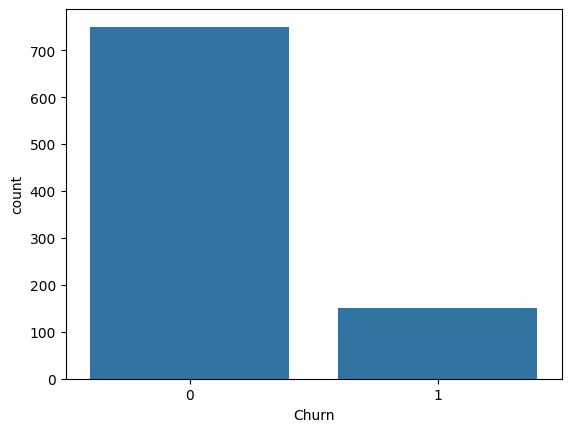

In [ ]:
# Visualiser graphiquement la variable churn

sns.countplot(x='Churn', data=dataset)
plt.show()


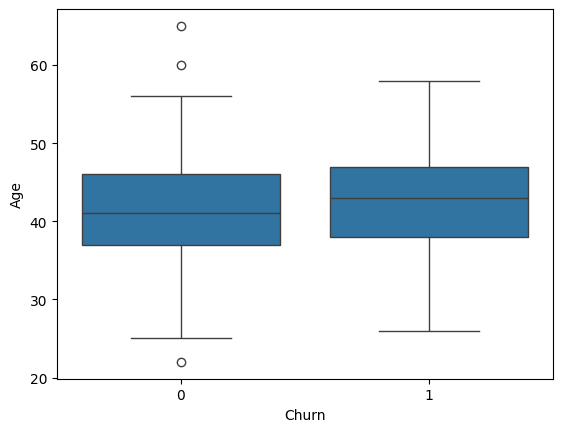

In [ ]:
# Visualiser le churn en fonction de l'âge

sns.boxplot(x='Churn', y='Age', data=dataset)
plt.show()

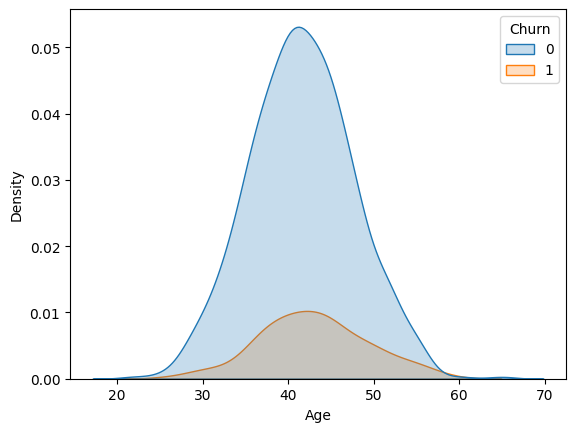

In [ ]:
# Visualiser le churn en fonction de l'âge en densité

sns.kdeplot(x='Age', data=dataset, hue='Churn', fill=True)
plt.show()


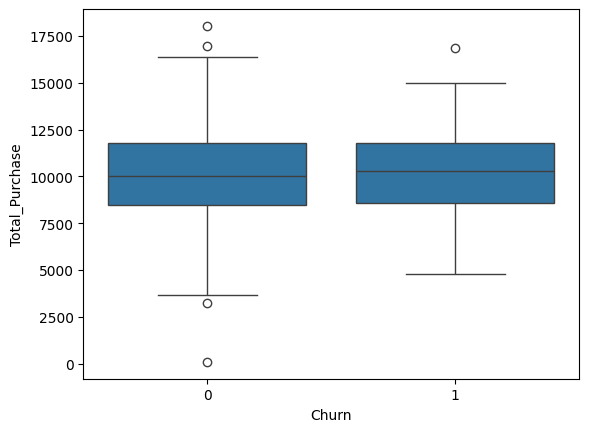

In [ ]:
# Visualiser le churn en fonction de total purchase

sns.boxplot(x='Churn', y='Total_Purchase', data=dataset)
plt.show()

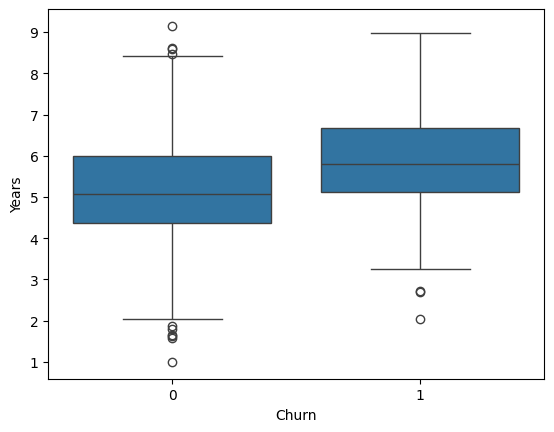

In [ ]:
# Visualiser le churn en fonction de Years

sns.boxplot(x='Churn', y='Years', data=dataset)
plt.show()

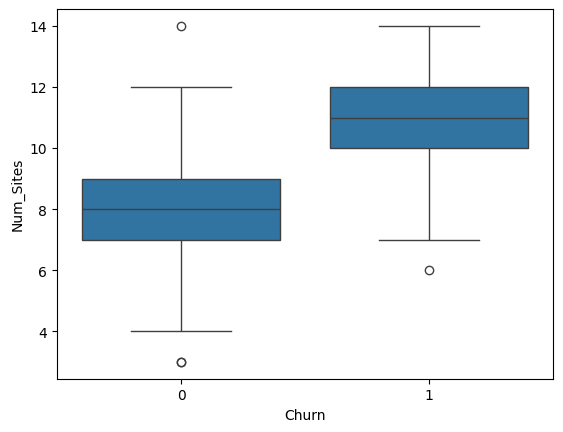

In [ ]:
# Visualiser le churn en fonction de Num_Sites

sns.boxplot(x='Churn', y='Num_Sites', data=dataset)
plt.show()

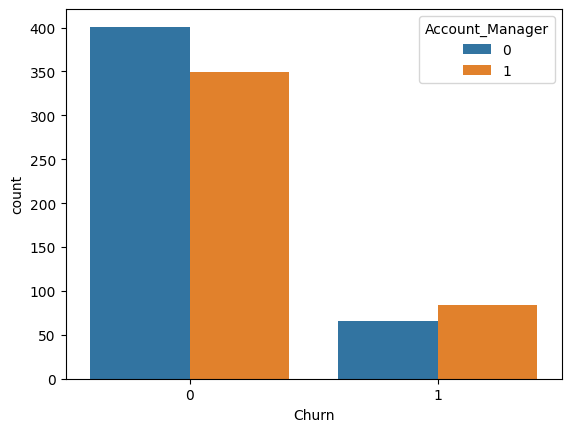

In [ ]:
# Visualiser le churn en fonction de account manager

sns.countplot(x='Churn', hue='Account_Manager', data=dataset)
plt.show()

## Modélisation

In [ ]:
# Isoler les X et y

X = dataset.drop('Churn', axis=1)
y = dataset['Churn']

# Entraîner une régression logistique avec statsmodels

import statsmodels.api as sm

X = sm.add_constant(X)
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.261624
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  900
Model:                          Logit   Df Residuals:                      894
Method:                           MLE   Df Model:                            5
Date:                Fri, 19 Jun 2026   Pseudo R-squ.:                  0.4193
Time:                        07:41:59   Log-Likelihood:                -235.46
converged:                       True   LL-Null:                       -405.51
Covariance Type:            nonrobust   LLR p-value:                 2.383e-71
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -19.3426      1.707    -11.328      0.000     -22.689     -15.996
Age           

In [ ]:
# Prédire le churn

# Partitionner les données en entraînement et test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,const,Age,Total_Purchase,Account_Manager,Years,Num_Sites
10,1.0,30.0,11575.37,1,5.22,8.0
334,1.0,40.0,6773.23,1,4.29,11.0
244,1.0,37.0,15070.32,0,6.91,6.0
678,1.0,43.0,5907.07,0,5.89,8.0
306,1.0,46.0,11538.57,1,7.93,10.0


In [ ]:
# Entraîner un modèle de régresson logistique avec statsmodels

model_sm = sm.Logit(y_train, X_train).fit()

# Prédire sur les données de test

y_pred_sm = model_sm.predict(X_test)
y_pred_class = [1 if p >= 0.5 else 0 for p in y_pred_sm]


Optimization terminated successfully.
         Current function value: 0.257054
         Iterations 8


In [ ]:
# Calculer les métriques de performances : accuracy, précision, rappel et f1 score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print('Accuracy:', accuracy_score(y_test, y_pred_class))
print('Precision:', precision_score(y_test, y_pred_class))
print('Recall:', recall_score(y_test, y_pred_class))
print('F1 score:', f1_score(y_test, y_pred_class))

Accuracy: 0.9
Precision: 0.7692307692307693
Recall: 0.625
F1 score: 0.6896551724137931


## Régression logistique avec sklearn

In [ ]:
# Entraîner une régression logistique avec sklearn

X = dataset.drop('Churn', axis=1)
y = dataset['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# Prédire sur les données de test

y_pred = model.predict(X_test)

# Calculer les métriques de performance

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 score:', f1_score(y_test, y_pred))

Accuracy: 0.8277777777777777
Precision: 0.5384615384615384
Recall: 0.21875
F1 score: 0.3111111111111111


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Standardisation des données

In [ ]:
# Standardisation des données avant régression

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 score:', f1_score(y_test, y_pred))



Accuracy: 0.9
Precision: 0.7692307692307693
Recall: 0.625
F1 score: 0.6896551724137931


## Ré-échantillonnage des données

In [ ]:
# Oversampling de la classe minoritaire

from imblearn.over_sampling import SMOTE


ratios = [0.2, 0.4, 0.6, 0.8, 1]

for ratio in ratios:

    smote = SMOTE(sampling_strategy=ratio, random_state=42)

    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    model = LogisticRegression()
    model.fit(X_train_resampled, y_train_resampled)

    y_pred = model.predict(X_test_scaled)

    print(f"\n===== Ratio : {ratio} =====")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 2))
    print("Precision:", round(precision_score(y_test, y_pred), 2))
    print("Recall   :", round(recall_score(y_test, y_pred), 2))
    print("F1-score :", round(f1_score(y_test, y_pred), 2))


===== Ratio : 0.2 =====
Accuracy : 0.9
Precision: 0.77
Recall   : 0.62
F1-score : 0.69

===== Ratio : 0.4 =====
Accuracy : 0.91
Precision: 0.76
Recall   : 0.69
F1-score : 0.72

===== Ratio : 0.6 =====
Accuracy : 0.91
Precision: 0.71
Recall   : 0.78
F1-score : 0.75

===== Ratio : 0.8 =====
Accuracy : 0.9
Precision: 0.69
Recall   : 0.78
F1-score : 0.74

===== Ratio : 1 =====
Accuracy : 0.86
Precision: 0.57
Recall   : 0.81
F1-score : 0.67
